Comparing my NorESM2.3 run with Dirk's KeyClim run before making simulations of volcanic eruptions. 

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob

In [2]:
from check_time import extract_vars

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35635,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39997,Total threads: 4
Dashboard: http://127.0.0.1:38109/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:38299,


2025-11-10 12:11:01,799 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:20:24,839 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:20:36,020 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:20:59,780 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:21:03,356 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:21:06,111 - distributed.nanny - WARNING - Restarting worker
2025-11-10 12:35:25,669 - distributed.nanny - WARNING - Restarting worker


In [4]:
"""
path_atm_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist"
glob_files = sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.19[7-9]*.nc"))
#glob_files = glob_files.append(sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.20*.nc")))
dr = pd.date_range(start="1975-01-01", end="2014-12-31", freq="MS")
dr = dr.strftime("%Y-%m").tolist()
dr
paths=[None]*len(dr)
for i, d in enumerate(dr):
    paths[i] = path_atm_KeyClim + f"/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.{d}.nc"

paths[0]
"""

'\npath_atm_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist"\nglob_files = sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.19[7-9]*.nc"))\n#glob_files = glob_files.append(sorted(glob(f"{path_atm_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.20*.nc")))\ndr = pd.date_range(start="1975-01-01", end="2014-12-31", freq="MS")\ndr = dr.strftime("%Y-%m").tolist()\ndr\npaths=[None]*len(dr)\nfor i, d in enumerate(dr):\n    paths[i] = path_atm_KeyClim + f"/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.cam.h0.{d}.nc"\n\npaths[0]\n'

In [5]:
# Vars I have extracted already:
#          "TREFHT", "AODVVOLC", "AOD_VIS", "SO2",
#          "TS", "U", "Z3", "O3", "FLNT", "FSNT", 
#          "FSNTOA", "DAYFOC", "OCNFRAC", "cb_O3", 
#          "O3_SRF", "PRECC", "PRECL", "OH", "SO2",
#          "SO2_SRF"
"""
extract_vars(fld="/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist",
             vars=["SO2_SRF"],  
             ystart=1975,
             yend=2014,
             outfld="/nird/projects/NS1004K/elihho/test_output",
             ow=True)
             #client = Client()
"""

'\nextract_vars(fld="/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/atm/hist",\n             vars=["SO2_SRF"],  \n             ystart=1975,\n             yend=2014,\n             outfld="/nird/projects/NS1004K/elihho/test_output",\n             ow=True)\n             #client = Client()\n'

In [6]:
path_atm = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [7]:
#client.close()

## 2m temperatures (1975-2014)

In [8]:
m2temp_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/TREFHT_h0_1975-2014.nc")
#m2temp_KeyClim

In [9]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

# Apply to the time coordinate
shifted_time = np.array([shift_one_month_back(t) for t in ds['time'].values])
shifted_time_KeyClim = np.array([shift_one_month_back(t) for t in m2temp_KeyClim['time'].values])

ds= ds.assign_coords(time=shifted_time)
m2temp_KeyClim =m2temp_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(ds["time"].values[:5])
print(m2temp_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [10]:
m2temp_KeyClim

<xarray.Dataset> Size: 106MB
Dimensions:    (lat: 192, lon: 288, time: 480, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 4kB 1975-01-01 00:00:00 ... 2014-12-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    time_bnds  (time, nbnd) object 8kB ...
    TREFHT     (time, lat, lon) float32 106MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03
    logname:           olivie
    host:              
    initial_file:      N1850vsls_tropstratchem_prep_f09_nt14_20220223_test14....
    topography_file:   /cluster/shared/noresm/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Mon Oct 20 13:09:37 2025: ncrcat -O -v TREFHT /project...
    NCO:               netCDF Operators version 5.3.0 (Homepage = http://nco....

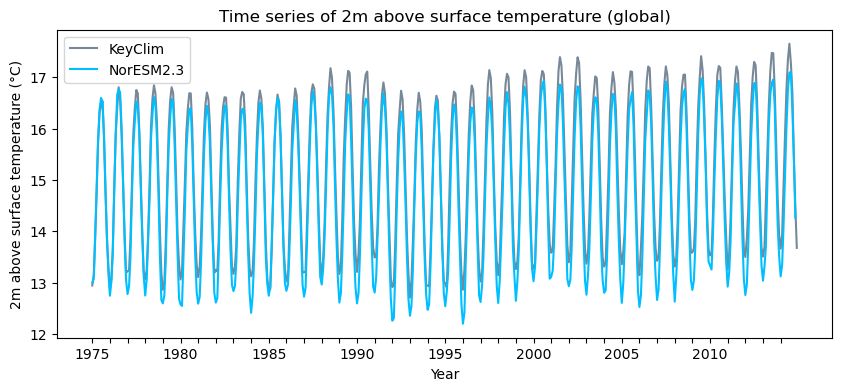

In [11]:
m2temp = "TREFHT"  

lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))

lat_KeyClim = m2temp_KeyClim["lat"]
weighted_lat_KeyClim = np.cos(np.deg2rad(lat_KeyClim))

ts = ds[m2temp].weighted(weighted_lat).mean(dim=["lat", "lon"]) - 272.15 # Area-weighted mean, convert from K to °C
ts_KeyClim = m2temp_KeyClim[m2temp].weighted(weighted_lat_KeyClim).mean(dim=["lat", "lon"]) -272.15

plt.figure(figsize=(10, 4))
ts_KeyClim.plot(color="lightslategray", label="KeyClim")
ts.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("2m above surface temperature (°C)")
plt.xlabel("Year")
plt.title("Time series of 2m above surface temperature (global)")
plt.legend()
plt.show()

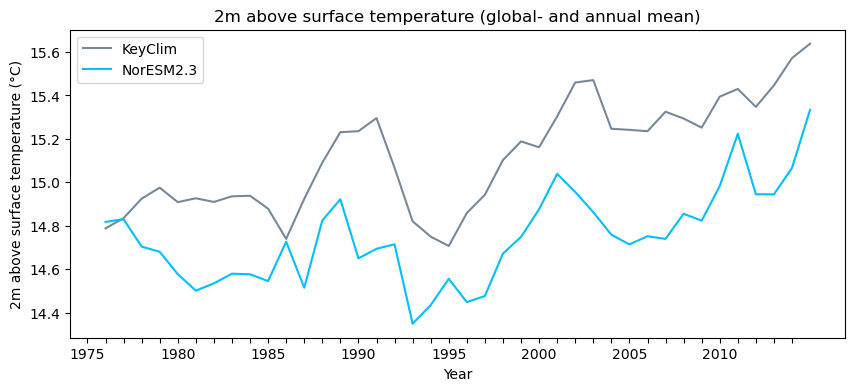

In [12]:
ts_year = ts.resample(time="1YE").mean(dim="time")
ts_KeyClim_year = ts_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
ts_KeyClim_year.plot(color="lightslategray", label="KeyClim")
ts_year.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("2m above surface temperature (°C)")
plt.xlabel("Year")
plt.title("2m above surface temperature (global- and annual mean)")
plt.legend()
plt.show()

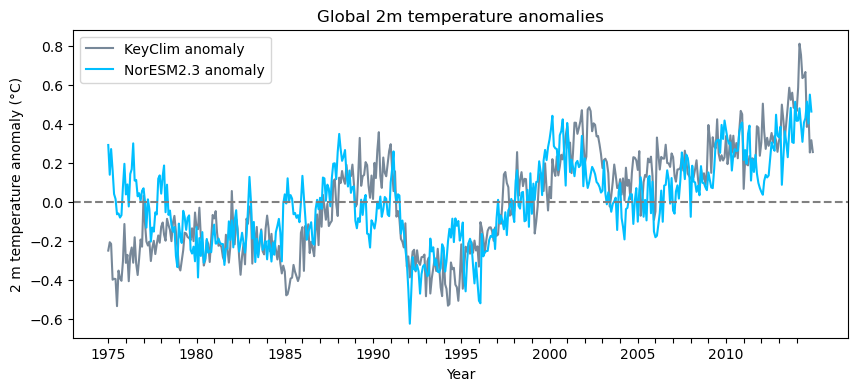

In [13]:
clim_ts = ts.groupby("time.month").mean("time")
clim_KeyClim = ts_KeyClim.groupby("time.month").mean("time")

ts_anom = ts.groupby("time.month") - clim_ts
ts_KeyClim_anom = ts_KeyClim.groupby("time.month") - clim_KeyClim

plt.figure(figsize=(10, 4))
ts_KeyClim_anom.plot(color="lightslategray", label="KeyClim anomaly")
ts_anom.plot(color="deepskyblue", label="NorESM2.3 anomaly")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("2 m temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Global 2m temperature anomalies")
plt.legend()
plt.show()

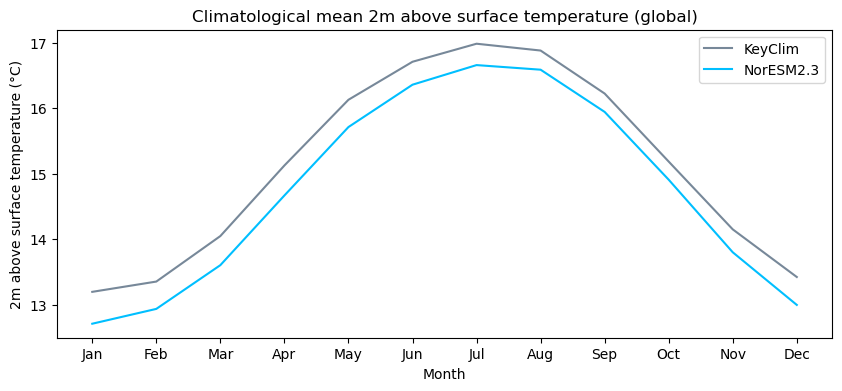

In [14]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


plt.figure(figsize=(10, 4))
plt.plot(months, clim_KeyClim.values, color="lightslategray", label="KeyClim")
plt.plot(months, clim_ts.values, color="deepskyblue", label="NorESM2.3")
plt.ylabel("2m above surface temperature (°C)")
plt.xlabel("Month")
plt.title("Climatological mean 2m above surface temperature (global)")
plt.legend()
plt.show()

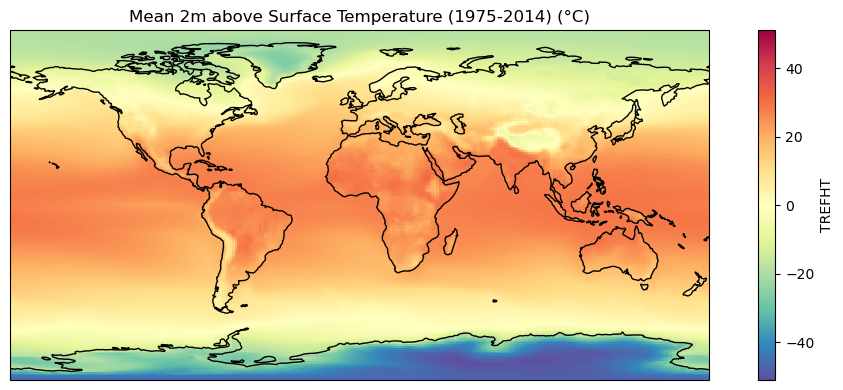

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10, 4), subplot_kw={'projection': ccrs.PlateCarree()})
mean_st = ds[m2temp].mean(dim="time")-272.15  # Convert from K to °C
mean_st.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Spectral_r')
ax.coastlines()
ax.set_title('Mean 2m above Surface Temperature (1975-2014) (°C)', fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
scandinavia_lat = slice(50, 84)
scandinavia_lon = slice(-10, 50)
mean_st_scandinavia = mean_st.sel(lat=scandinavia_lat, lon=scandinavia_lon)

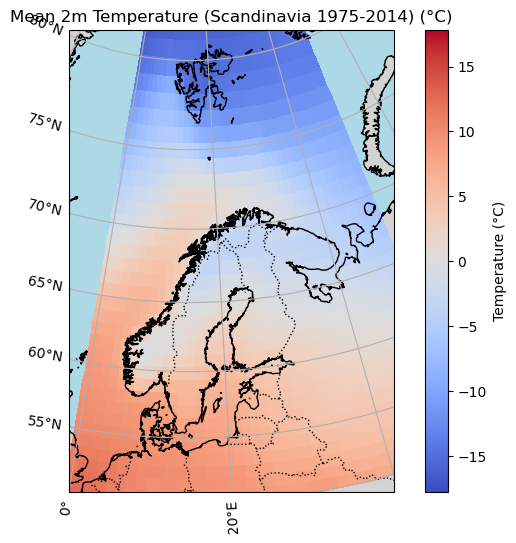

In [17]:
proj = ccrs.LambertConformal(central_longitude=15, central_latitude=60)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)
ax.set_extent([0, 40, 50, 81], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

mean_st_scandinavia.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    cbar_kwargs={'label': 'Temperature (°C)'}
)

ax.set_title("Mean 2m Temperature (Scandinavia 1975-2014) (°C)", fontsize=12)
plt.show()

## Aerosol Optical Depth

In [18]:
aod_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/AOD_VIS_h0_1975-2014.nc")
daylight_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/DAYFOC_h0_1975-2014.nc")

aod_KeyClim =aod_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(aod_KeyClim["time"].values[:5])

daylight_KeyClim =daylight_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(daylight_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


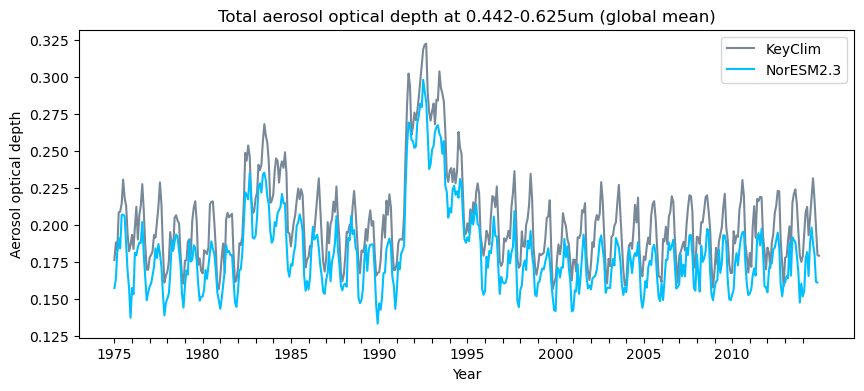

In [19]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
aod_volc = "AODVVOLC" # CMIP6 volcanic AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
ts_aod_KeyClim = aod_KeyClim[aod500].weighted(weighted_lat_KeyClim).mean(dim=["lat", "lon"])
daylight_monthly_KeyClim = daylight_KeyClim[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod_KeyClim = ts_aod_KeyClim / daylight_monthly_KeyClim

plt.figure(figsize=(10, 4))
ts_aod_KeyClim.plot(color = "lightslategray", label = "KeyClim")
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


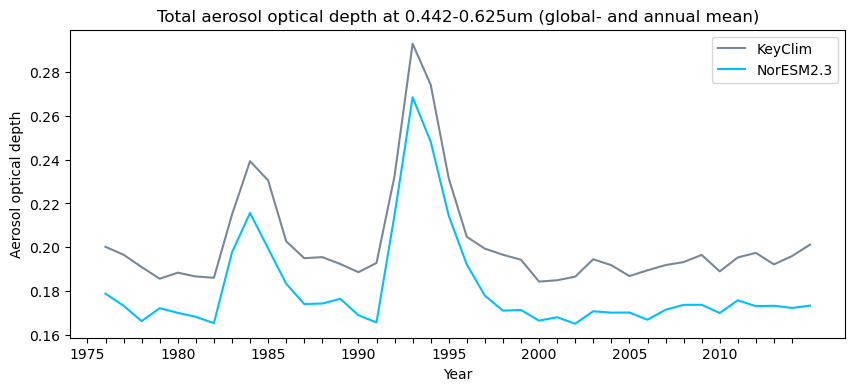

In [21]:
ts_aod_year = ts_aod.resample(time="1YE").mean()
ts_aod_KeyClim_year = ts_aod_KeyClim.resample(time="1YE").mean()

plt.figure(figsize=(10, 4))
ts_aod_KeyClim_year.plot(color = "lightslategray", label = "KeyClim")
ts_aod_year.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global- and annual mean)")
plt.legend()
plt.show()

## Wind plots

In [22]:
u_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/U_h0_1975-2014.nc")
U_KeyClim =u_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(U_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


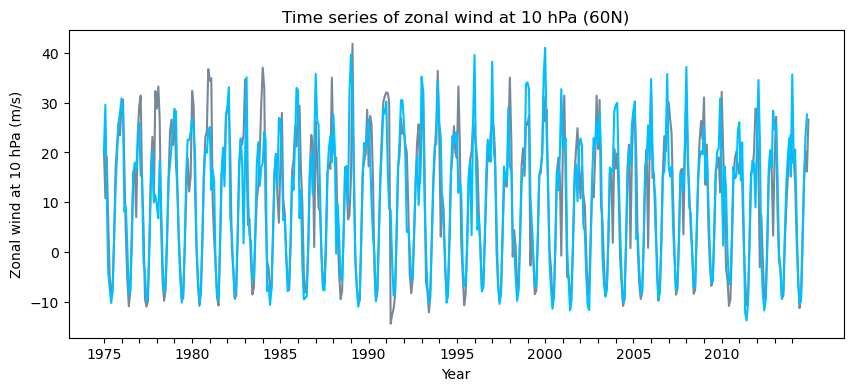

In [23]:
zonal_wind = "U"  # Zonal wind at 10 hPa
u_60N = ds[zonal_wind].sel(lat=60, method="nearest")
ts_wind = u_60N.sel(lev=10, method="nearest").mean(dim="lon")
u_60N_KeyClim = U_KeyClim[zonal_wind].sel(lat=60, method="nearest")
ts_wind_KeyClim = u_60N_KeyClim.sel(lev=10, method="nearest").mean(dim="lon")

plt.figure(figsize=(10, 4))
ts_wind_KeyClim.plot(color = "lightslategray", label = "KeyClim")
ts_wind.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("Zonal wind at 10 hPa (m/s)")
plt.title("Time series of zonal wind at 10 hPa (60N)")
plt.show()

/tmp/ipykernel_672520/3618889734.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


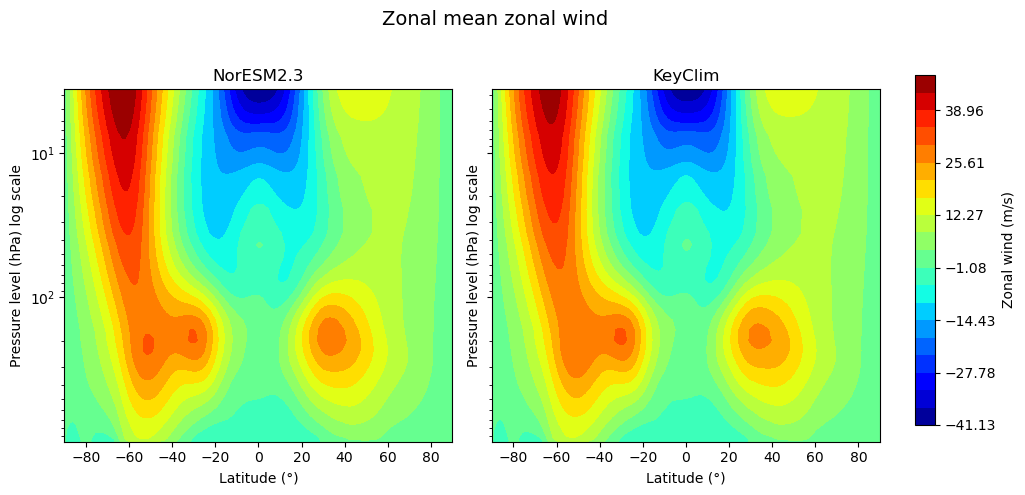

In [24]:
U = ds[zonal_wind].mean(dim="lon")
u_lat = U["lat"].values
u_lev = U["lev"].values
U_mean = U.mean(dim="time")
U_mean = U_mean.transpose("lev", "lat")
U_mean = U_mean.values

U_KeyClim = u_KeyClim[zonal_wind].mean(dim="lon")
u_lat_KeyClim = U_KeyClim["lat"].values
u_lev_KeyClim = U_KeyClim["lev"].values
U_mean_KeyClim = U_KeyClim.mean(dim="time")
U_mean_KeyClim = U_mean_KeyClim.transpose("lev", "lat")
U_mean_KeyClim = U_mean_KeyClim.values

vmin = min(U_mean.min(), U_mean_KeyClim.min())
vmax = max(U_mean.max(), U_mean_KeyClim.max())
levels = np.linspace(vmin, vmax, 21)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax = ax.flatten()

# NorESM2.3
ax[0].set_yscale("log")
cf0 = ax[0].contourf(u_lat, u_lev, U_mean, cmap="jet", levels=levels)
ax[0].set_ylim(u_lev.max(), u_lev.min())
ax[0].set_xlabel("Latitude (°)")
ax[0].set_ylabel("Pressure level (hPa) log scale")
ax[0].set_title("NorESM2.3")

# KeyClim
ax[1].set_yscale("log")
cf1 = ax[1].contourf(u_lat_KeyClim, u_lev_KeyClim, U_mean_KeyClim, cmap="jet", levels=levels)
ax[1].set_ylim(u_lev.max(), u_lev.min())
ax[1].set_xlabel("Latitude (°)")
ax[1].set_ylabel("Pressure level (hPa) log scale")
ax[1].set_title("KeyClim")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(cf0, cax=cbar_ax, label="Zonal wind (m/s)")
fig.suptitle("Zonal mean zonal wind", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.96]) 
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


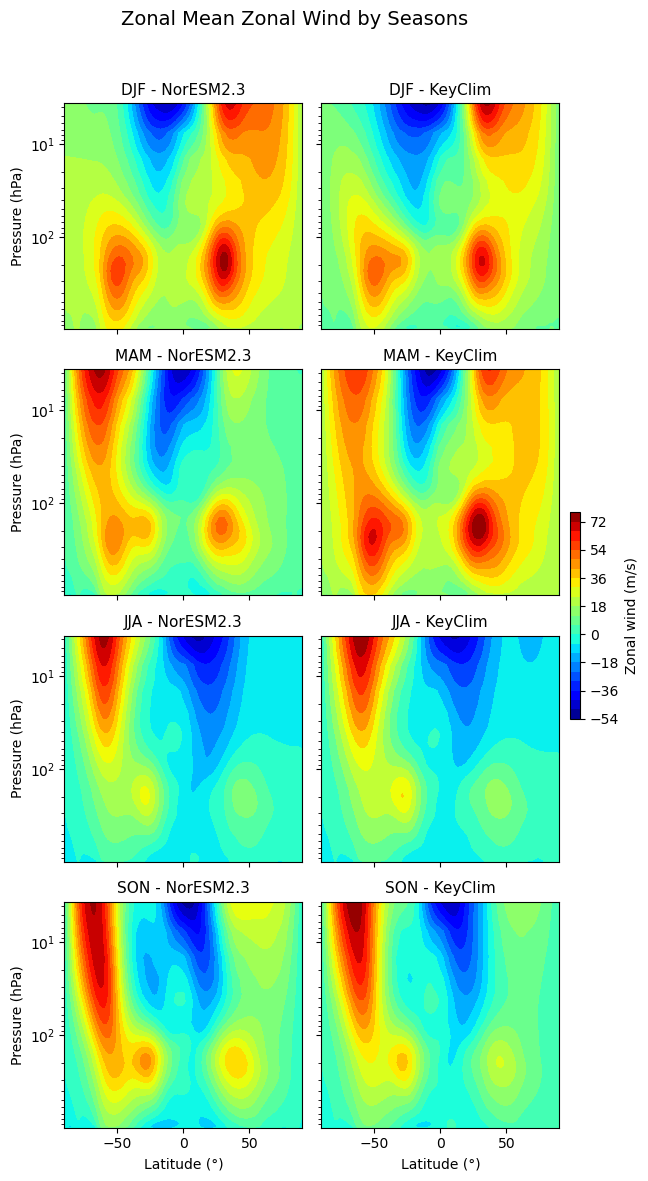

In [25]:
U_seasons = U.groupby("time.season")
U_season_KeyClim = U_KeyClim.groupby("time.season")

season_order = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(4, 2, figsize=(6, 12), sharex=True, sharey=True)

for i, season in enumerate(season_order):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    if season in U_seasons.groups:
        data1 = U_seasons[season]
        U_meanseason1 = data1.mean(dim="time").transpose("lev", "lat")
        cf1 = ax_left.contourf(u_lat, u_lev, U_meanseason1.values, cmap="jet", levels=21)
        ax_left.set_yscale("log")
        ax_left.set_ylim(u_lev.max(), u_lev.min())
        ax_left.set_title(f"{season} - NorESM2.3", fontsize=11)
        ax_left.set_ylabel("Pressure (hPa)")
        if i == len(season_order) - 1:
            ax_left.set_xlabel("Latitude (°)")

    if season in U_season_KeyClim.groups:
        data2 = U_season_KeyClim[season]
        U_meanseason2 = data2.mean(dim="time").transpose("lev", "lat")
        cf2 = ax_right.contourf(u_lat, u_lev, U_meanseason2.values, cmap="jet", levels=21)
        ax_right.set_yscale("log")
        ax_right.set_ylim(u_lev.max(), u_lev.min())
        ax_right.set_title(f"{season} - KeyClim", fontsize=11)
        if i == len(season_order) - 1:
            ax_right.set_xlabel("Latitude (°)")

fig.suptitle("Zonal Mean Zonal Wind by Seasons", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
cbar = fig.colorbar(cf2, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Zonal wind (m/s)")

plt.show()


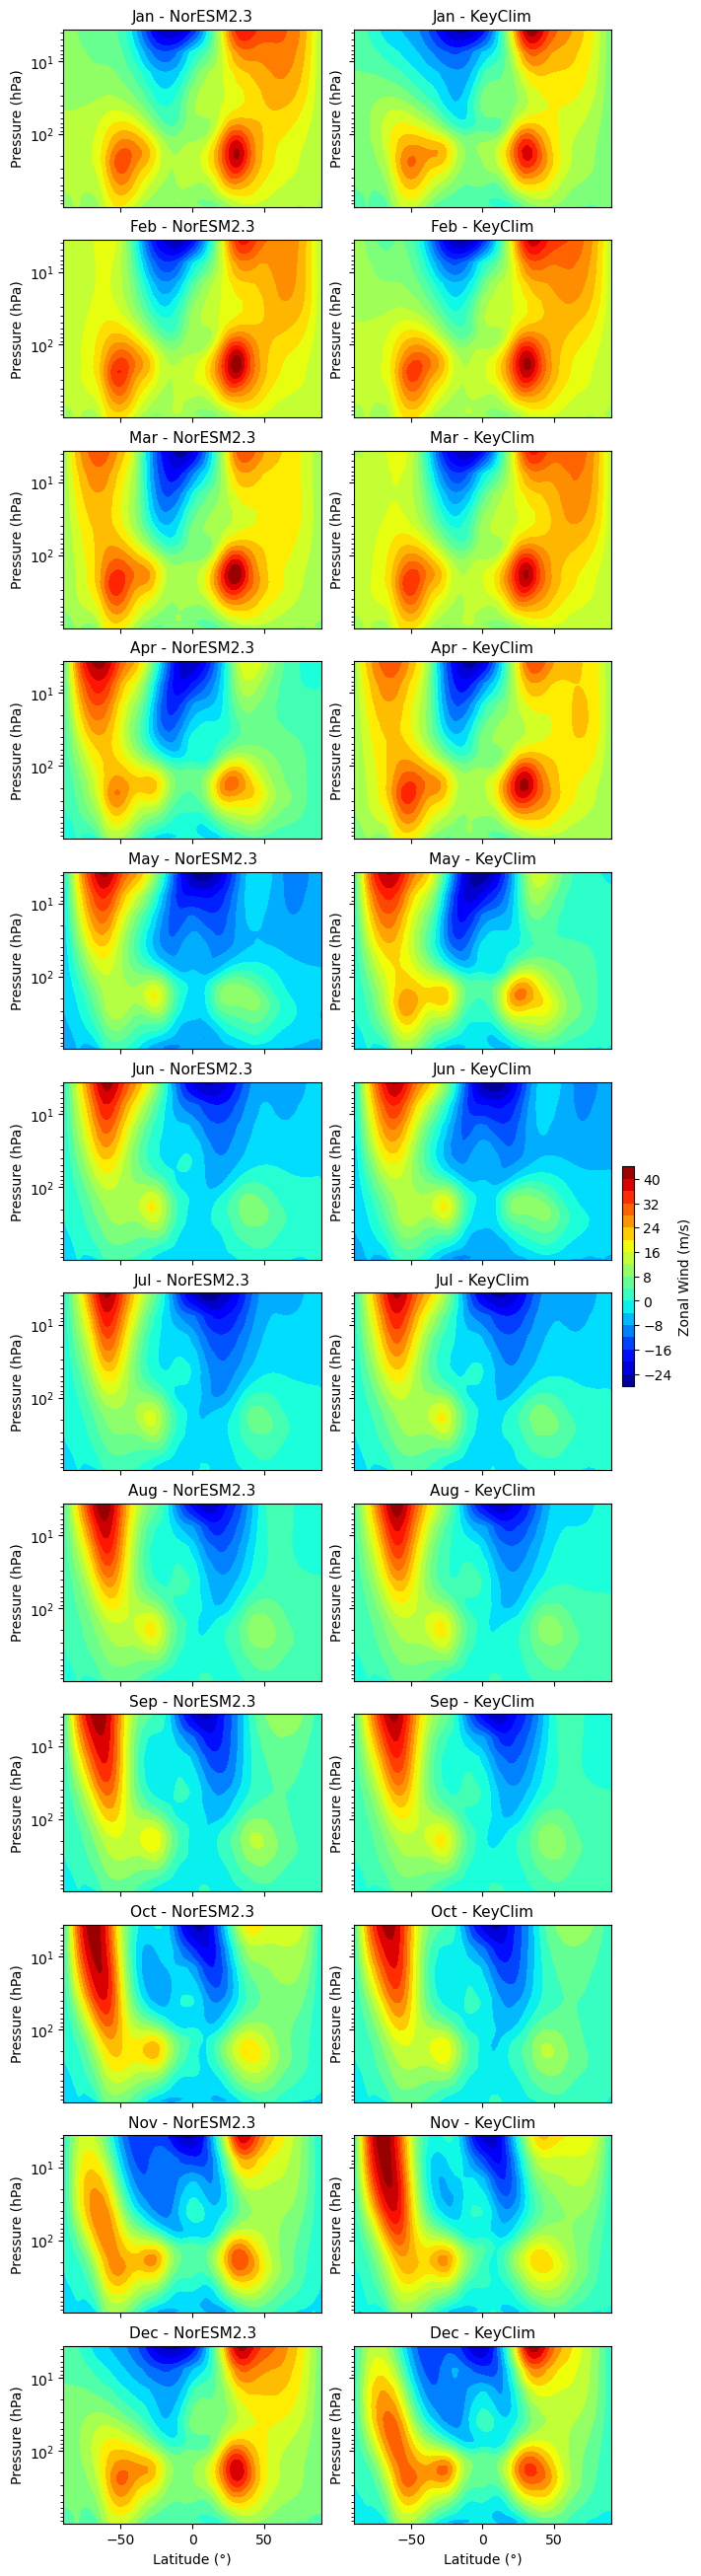

In [27]:
U_monthly = U.groupby("time.month")
U_monthly_KeyClim = U_KeyClim.groupby("time.month")

month_labels = ["Jan", "Feb", "Mar", "Apr", 
                "May", "Jun", "Jul", "Aug", 
                "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(
    nrows=12, ncols=2, figsize=(7, 26),
    sharex=True, sharey=True, constrained_layout=True
)

def plot_zonal_mean(ax, data_group, month_idx, model_name):
    if month_idx not in data_group.groups:
        return None

    data = data_group[month_idx]
    U_mean = data.mean(dim="time").transpose("lev", "lat")
    cf = ax.contourf(u_lat, u_lev, U_mean, cmap="jet", levels=21)
    ax.set_yscale("log")
    ax.set_ylim(u_lev.max(), u_lev.min())
    ax.set_title(f"{month_labels[month_idx - 1]} - {model_name}", fontsize=11)

    if month_idx == 12:
        ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Pressure (hPa)")

    return cf

for i, month_name in enumerate(month_labels, start=1):
    ax_left, ax_right = axes[i-1, :]

    cf1 = plot_zonal_mean(ax_left, U_monthly, month_idx=i, model_name="NorESM2.3")
    cf2 = plot_zonal_mean(ax_right, U_monthly_KeyClim, month_idx=i, model_name="KeyClim")


cf_final = cf2 or cf1
if cf_final:
    cbar = fig.colorbar(cf_final, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label("Zonal Wind (m/s)")

plt.show()

In [28]:
# Helper function to set latitudinal limits
# from https://nordicesmhub.github.io/NEGI-Abisko-2019/training/example_NorthPolarStereo_projection.html
def polarCentral_set_latlim(lat_lims, ax):
    # Set extent in geographic coordinates
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]], crs=ccrs.PlateCarree())

    # Make circular boundary (center of axes)
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
"""
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    constrained_layout=True
)

mean_u = ds[zonal_wind].sel(lev = 10, method = "nearest").mean(dim="time")
polarCentral_set_latlim((20, 90), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_u.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
    center=0,
)

plt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)
plt.show()
"""


'\nfig, ax = plt.subplots(\n    1, 1,\n    figsize=(16, 8),\n    subplot_kw={\'projection\': ccrs.NorthPolarStereo()},\n    constrained_layout=True\n)\n\nmean_u = ds[zonal_wind].sel(lev = 10, method = "nearest").mean(dim="time")\npolarCentral_set_latlim((20, 90), ax)\nax.add_feature(cfeature.COASTLINE, linewidth=0.5)\nax.add_feature(cfeature.BORDERS, linewidth=0.3)\nax.gridlines(draw_labels=False, linewidth=0.2)\n\nmean_u.plot(\n    ax=ax,\n    transform=ccrs.PlateCarree(),\n    cmap="Spectral_r",\n    center=0,\n)\n\nplt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)\nplt.show()\n'

In [29]:
"""
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo()},
    constrained_layout=True
)

polarCentral_set_latlim((-90, -20), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_u.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",
    center=0,
)

plt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)
plt.show()
"""


'\nfig, ax = plt.subplots(\n    1, 1,\n    figsize=(16, 8),\n    subplot_kw={\'projection\': ccrs.SouthPolarStereo()},\n    constrained_layout=True\n)\n\npolarCentral_set_latlim((-90, -20), ax)\nax.add_feature(cfeature.COASTLINE, linewidth=0.5)\nax.add_feature(cfeature.BORDERS, linewidth=0.3)\nax.gridlines(draw_labels=False, linewidth=0.2)\n\nmean_u.plot(\n    ax=ax,\n    transform=ccrs.PlateCarree(),\n    cmap="Spectral_r",\n    center=0,\n)\n\nplt.suptitle("Zonal wind at 10 hPa (m/s)", fontsize=16)\nplt.show()\n'

## Ozone

In [30]:
o3_surf_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/O3_SRF_h0_1975-2014.nc")
o3_surf_KeyClim =o3_surf_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(o3_surf_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


Exception ignored in: <function CachingFileManager.__del__ at 0x7f7a59733100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


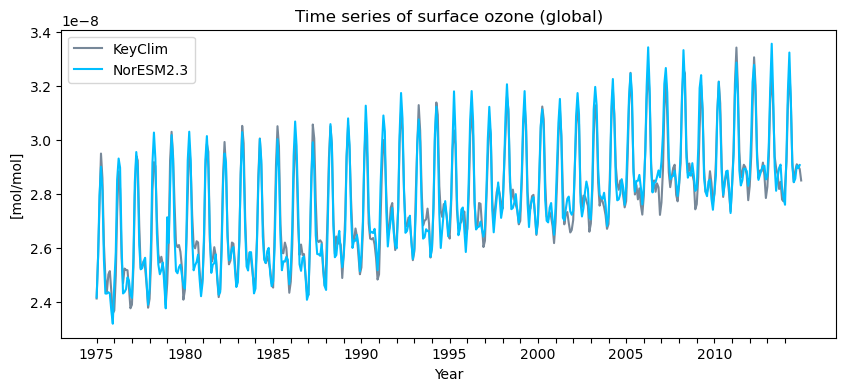

In [31]:
surf_o3 = "O3_SRF"
ts_o3 = ds[surf_o3].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_o3_KeyClim = o3_surf_KeyClim[surf_o3].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
ts_o3_KeyClim.plot(color="lightslategray", label = "KeyClim")
ts_o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("Time series of surface ozone (global)")
plt.legend() 
plt.show()

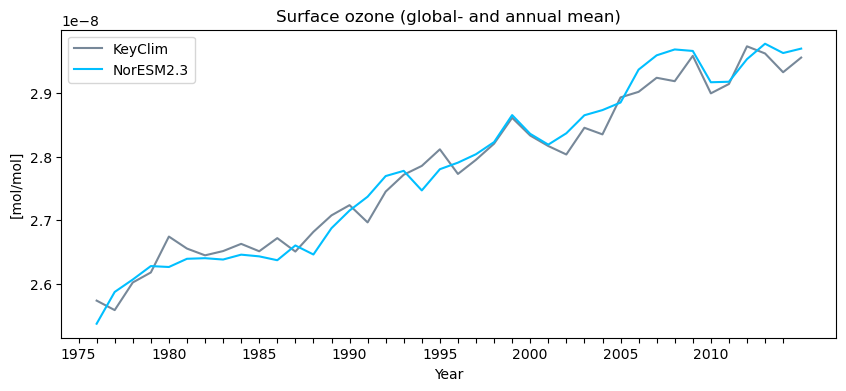

In [32]:
ts_o3_year = ts_o3.resample(time="1YE").mean()
ts_o3_KeyClim_year = ts_o3_KeyClim.resample(time="1YE").mean()

plt.figure(figsize=(10, 4))
ts_o3_KeyClim_year.plot(color="lightslategray", label = "KeyClim")
ts_o3_year.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("Surface ozone (global- and annual mean)")
plt.legend()
plt.show()

In [33]:
o3_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/O3_h0_1975-2014.nc")

o3_KeyClim =o3_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(o3_KeyClim["time"].values[:5])

cb_o3_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/cb_O3_h0_1975-2014.nc")
cb_o3_KeyClim = cb_o3_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(cb_o3_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [34]:
ds["cb_O3"]

<xarray.DataArray 'cb_O3' (time: 477, lat: 192, lon: 288)> Size: 106MB
dask.array<concatenate, shape=(477, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 4kB 1975-01-01 00:00:00 ... 2014-11-01 00:00:00
Attributes:
    units:         kg/m2
    long_name:     cb_O3 in column
    cell_methods:  time: mean

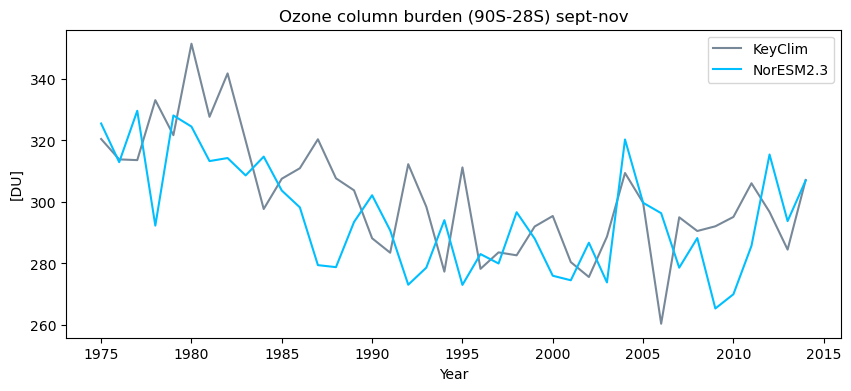

In [35]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"
o3_hole_months = [9, 10, 11]       # septober, october, november
o3_column = ds[cb_o3].sel(lat = slice(-90, -28)).mean(dim=["lon", "lat"])
o3_column = o3_column.where(o3_column["time.month"].isin(o3_hole_months), drop=True)
o3_yearly_mean = o3_column.groupby('time.year').mean(dim='time') * DU

cb_o3_column_KeyClim = cb_o3_KeyClim[cb_o3].sel(lat = slice(-90, -28)).mean(dim=["lon", "lat"])
cb_o3_column_KeyClim = cb_o3_column_KeyClim.where(cb_o3_column_KeyClim["time.month"].isin(o3_hole_months), drop=True)
cb_o3_yearly_mean_KeyClim = cb_o3_column_KeyClim.groupby('time.year').mean(dim='time') * DU

plt.figure(figsize=(10, 4))
cb_o3_yearly_mean_KeyClim.plot(color = "lightslategray", label = "KeyClim")
o3_yearly_mean.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[DU]")
plt.xlabel("Year")
plt.title("Ozone column burden (90S-28S) sept-nov")
plt.legend()
plt.show()

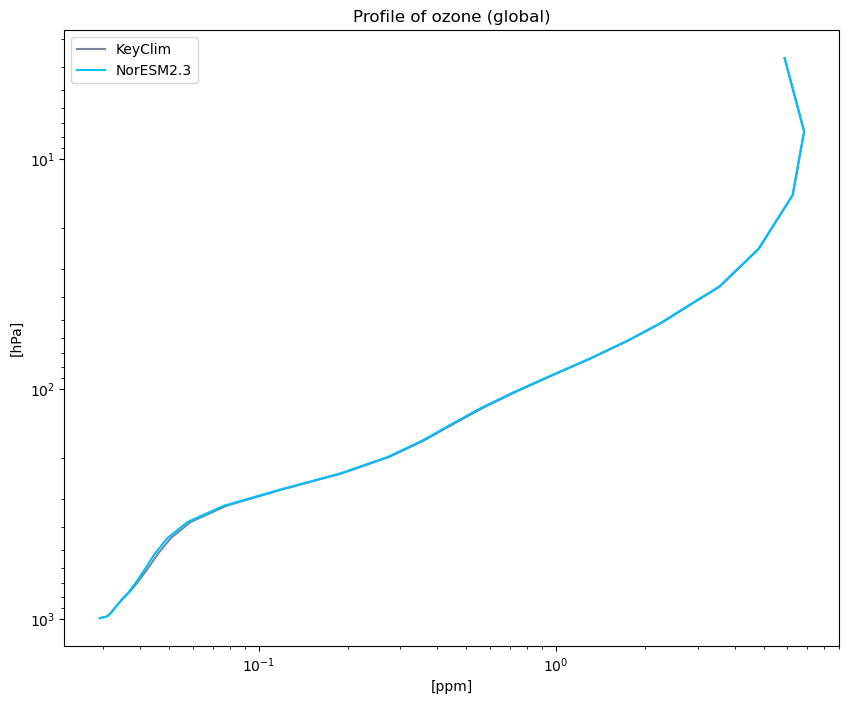

In [36]:
ppm_conversion_factor = 1e6  # 1 mol/mol = 1,000,000 ppm
o3 = "O3"
o3_profile = ds[o3].mean(dim=["lat", "lon", "time"])
o3_profile = o3_profile.transpose("lev")
o3_profile = o3_profile.values * ppm_conversion_factor

o3_profile_KeyClim = o3_KeyClim[o3].mean(dim=["lat", "lon", "time"])
o3_profile_KeyClim = o3_profile_KeyClim.transpose("lev")
o3_profile_KeyClim = o3_profile_KeyClim.values * ppm_conversion_factor

plt.figure(figsize=(10, 8))
plt.plot(o3_profile_KeyClim, o3_KeyClim["lev"], color = "lightslategray", label = "KeyClim")
plt.plot(o3_profile, ds["lev"], color = "deepskyblue", label = "NorESM2.3")
plt.yscale("log")
plt.xscale("log")
plt.gca().invert_yaxis()
plt.ylabel("[hPa]")
plt.xlabel("[ppm]")
plt.title("Profile of ozone (global)")
plt.legend()
plt.show()

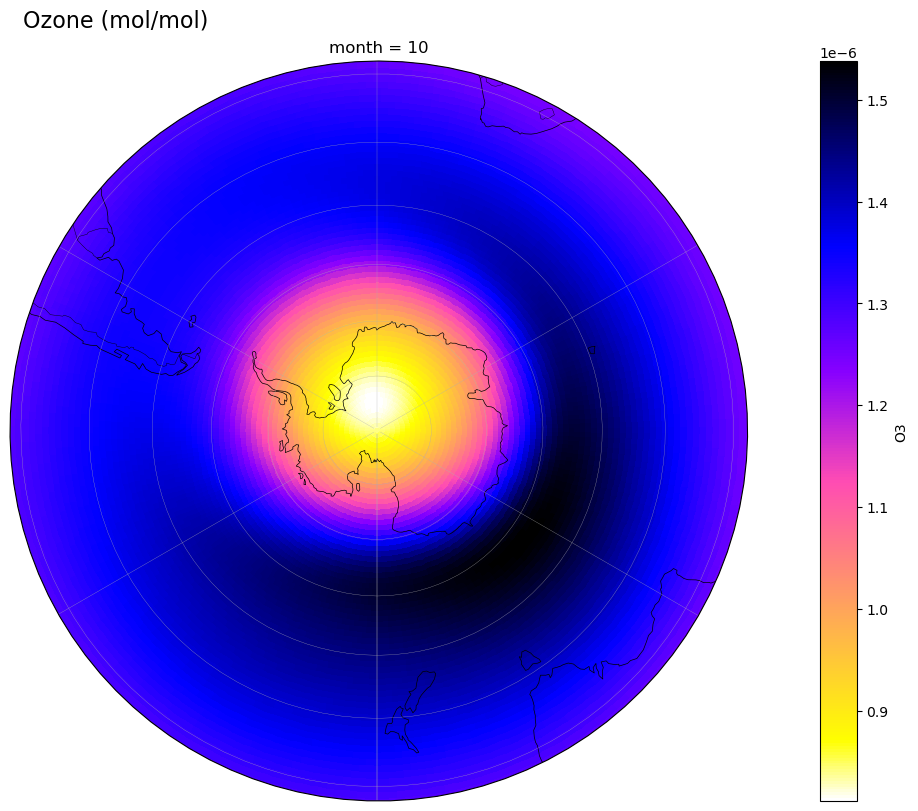

In [37]:
monthly = ds[o3].groupby("time.month").mean("time")
mean_o3 = monthly.mean(dim="lev")
fig, ax = plt.subplots(
    1, 1,
    figsize=(16, 8),
    subplot_kw={'projection': ccrs.SouthPolarStereo()},
    constrained_layout=True
)

polarCentral_set_latlim((-90, -28), ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=False, linewidth=0.2)

mean_o3[9].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="gnuplot2_r",
)

plt.suptitle("Ozone (mol/mol)", fontsize=16)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
plt.show()

## Radiation TOA

In [38]:
lw_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FLNT_h0_1975-2014.nc")

lw_KeyClim =lw_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(lw_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


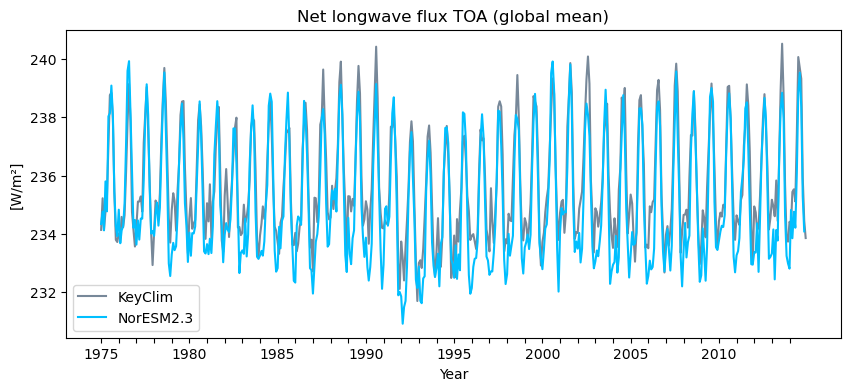

In [39]:
lw_toa = "FLNT"
lw_rad_toa = ds[lw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
lw_rad_toa_KeyClim = lw_KeyClim[lw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
lw_rad_toa_KeyClim.plot(color="lightslategray", label = "KeyClim")
lw_rad_toa.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net longwave flux TOA (global mean)")
plt.legend()
plt.show()

In [40]:
sw_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FSNT_h0_1975-2014.nc")

sw_KeyClim =sw_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(sw_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


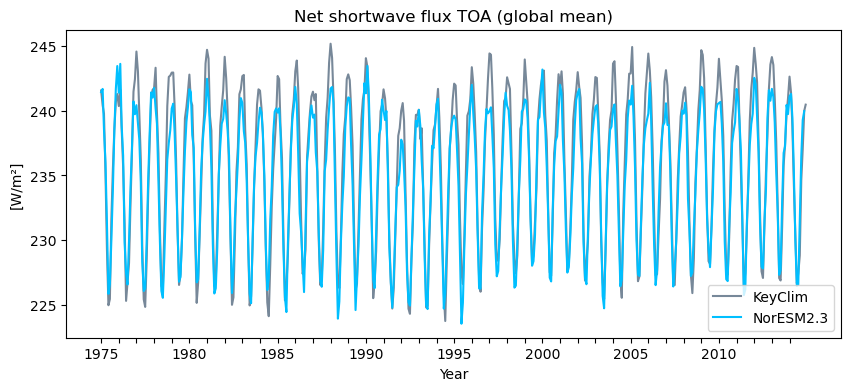

In [41]:
sw_toa = "FSNT"
sw_rad_toa = ds[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
sw_rad_toa_KeyClim = sw_KeyClim[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
sw_rad_toa_KeyClim.plot(color="lightslategray", label = "KeyClim")
sw_rad_toa.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net shortwave flux TOA (global mean)")
plt.legend()
plt.show()

In [42]:
sol_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/FSNTOA_h0_1975-2014.nc")

sol_KeyClim =sol_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(sol_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


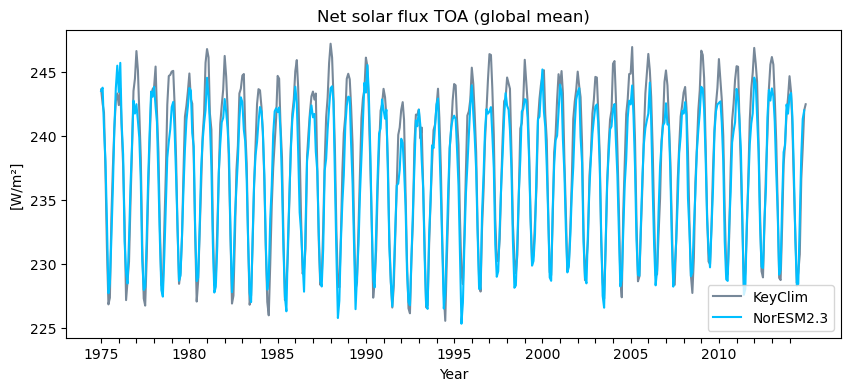

In [43]:
sw_toa = "FSNTOA"
sw_rad_toa = ds[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])
sw_rad_toa_KeyClim = sol_KeyClim[sw_toa].weighted(weighted_lat).mean(dim=["lat", "lon"])

plt.figure(figsize=(10, 4))
sw_rad_toa_KeyClim.plot(color = "lightslategray", label = "KeyClim")
sw_rad_toa.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[W/m²]")
plt.title("Net solar flux TOA (global mean)")
plt.legend()
plt.show()

## ENSO phase

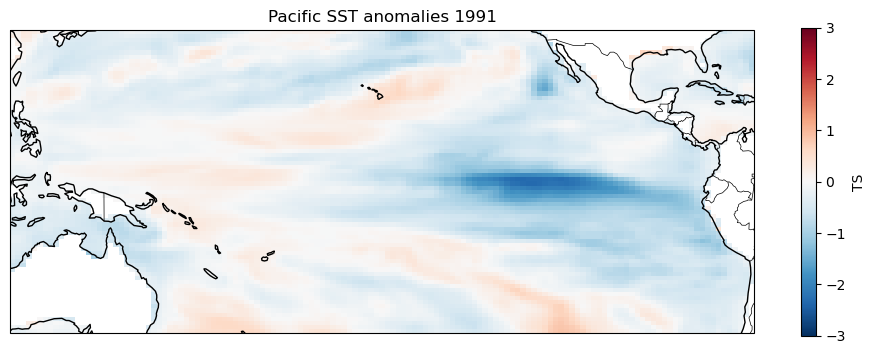

In [44]:
ocn = "OCNFRAC"    # Ocean fraction
temp_s = "TS"      # surface temperature

temp_surf = ds[temp_s]  
ocean_frac = ds[ocn]

temp_surf_ocean = temp_surf.where(ocean_frac > 0)
sst_1991 = temp_surf_ocean.sel(time=slice("1991-01-01", "1991-12-01"))
baseline = temp_surf_ocean.groupby("time.month").mean("time")            # baseline =the whole dataset mean
sst_anom = sst_1991.groupby("time.month") - baseline

sst_anom_dec = sst_anom.mean(dim="time")
pacific = sst_anom_dec.sel(lon=slice(120, 290), lat =slice(-35, 35))

plt.figure(figsize=(12,4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
pacific.plot(ax=ax, transform=ccrs.PlateCarree(),
             cmap="RdBu_r", vmin=-3, vmax=3, add_colorbar=True)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Pacific SST anomalies 1991")
plt.show()



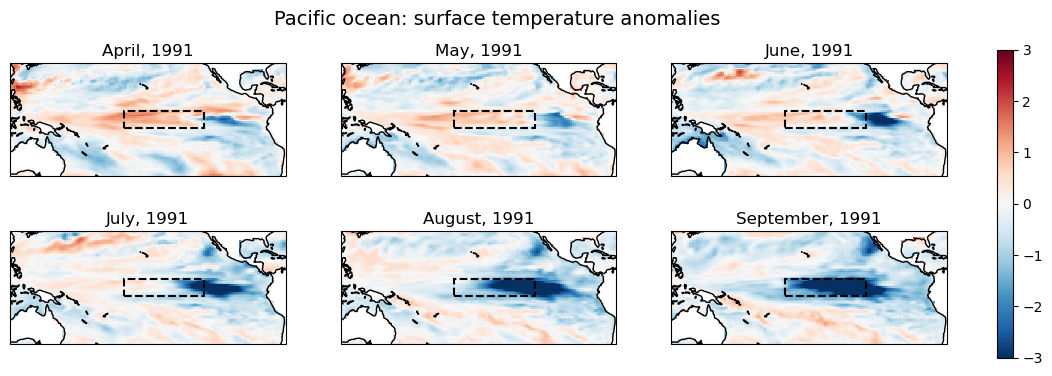

In [45]:
months_eruption = [4, 5, 6, 7, 8, 9] # april, may, june, july, august, september
nino_lat_min, nino_lat_max = -5, 5
nino_lon_min, nino_lon_max = 190, 240

fig, axes = plt.subplots(2, 3, figsize=(13, 4),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    sharex=True, sharey=True
)
axes = axes.flatten()

for ax, month in zip(axes, months_eruption):
    sst_month = sst_anom.sel(time=sst_anom["time.month"] == month)
    sst_month_mean = sst_month.mean(dim="time")
    pacific_month = sst_month_mean.sel(lon=slice(120, 290), lat=slice(-35, 35))

    pcm = pacific_month.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"{calendar.month_name[month]}, 1991")

    rect = Rectangle(
        (nino_lon_min, nino_lat_min),
        nino_lon_max - nino_lon_min,
        nino_lat_max - nino_lat_min,
        facecolor='none',
        edgecolor='black',
        linewidth=1.5,
        linestyle='--',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)


fig.suptitle("Pacific ocean: surface temperature anomalies", fontsize=14)
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.02)
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


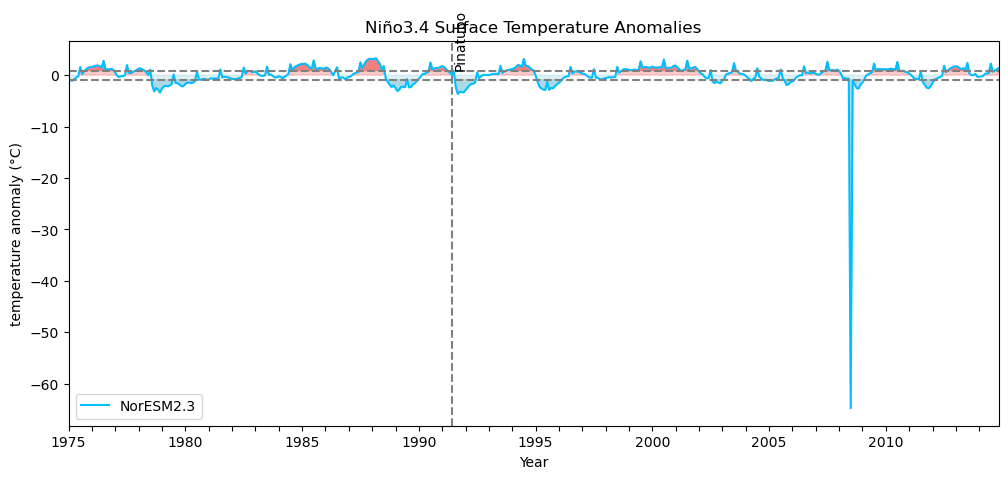

In [46]:
baseline = temp_surf_ocean.groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7f01743772e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


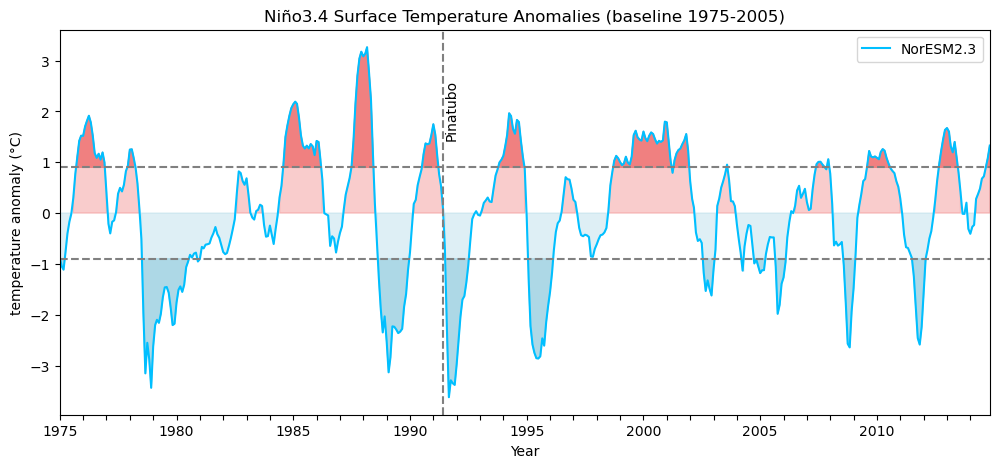

In [47]:
baseline = temp_surf_ocean.sel(time=slice("1975-01-01", "2005-01-01")).groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies (baseline 1975-2005)")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

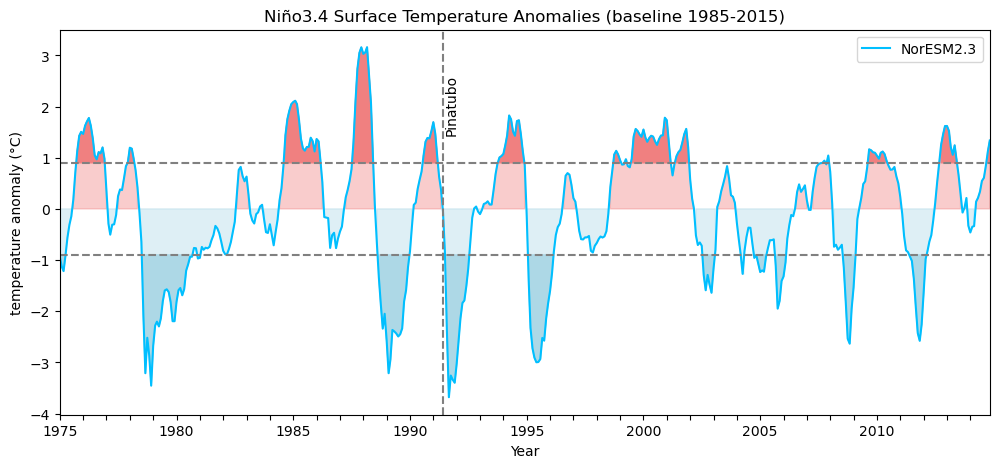

In [49]:
baseline = temp_surf_ocean.sel(time=slice("1985-01-01", "2014-12-01")).groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies (baseline 1985-2015)")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

In [50]:
ocn_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/OCNFRAC_h0_1975-2014.nc")
tsurf_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/TS_h0_1975-2014.nc")

ocn_KeyClim =ocn_KeyClim.assign_coords(time=shifted_time_KeyClim)
tsurf_KeyClim =tsurf_KeyClim.assign_coords(time=shifted_time_KeyClim)


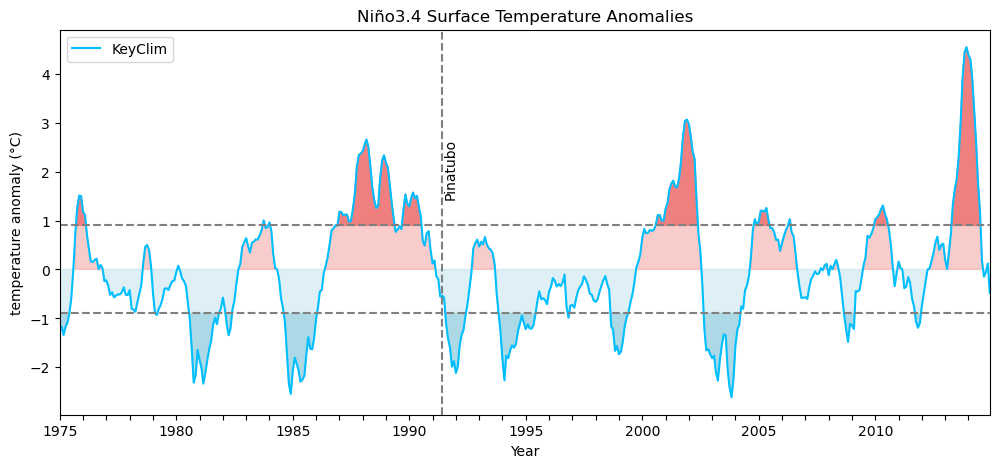

In [51]:
temp_surf_KeyClim = tsurf_KeyClim[temp_s]  
ocean_frac_KeyClim = ocn_KeyClim[ocn]

temp_surf_ocean_KeyClim = temp_surf_KeyClim.where(ocean_frac_KeyClim > 0)
base_KeyClim = temp_surf_ocean_KeyClim.groupby("time.month").mean("time")
sst_anom_KeyClim = temp_surf_ocean_KeyClim.groupby("time.month") - base_KeyClim
sst_enso_KeyClim = sst_anom_KeyClim.sel(lon=slice(nino_lon_min, nino_lon_max), lat=slice(nino_lat_min, nino_lat_max))
sst_enso_KeyClim = sst_enso_KeyClim.mean(dim=["lat", "lon"])

time = sst_enso_KeyClim["time"].values
values = sst_enso_KeyClim.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="KeyClim")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

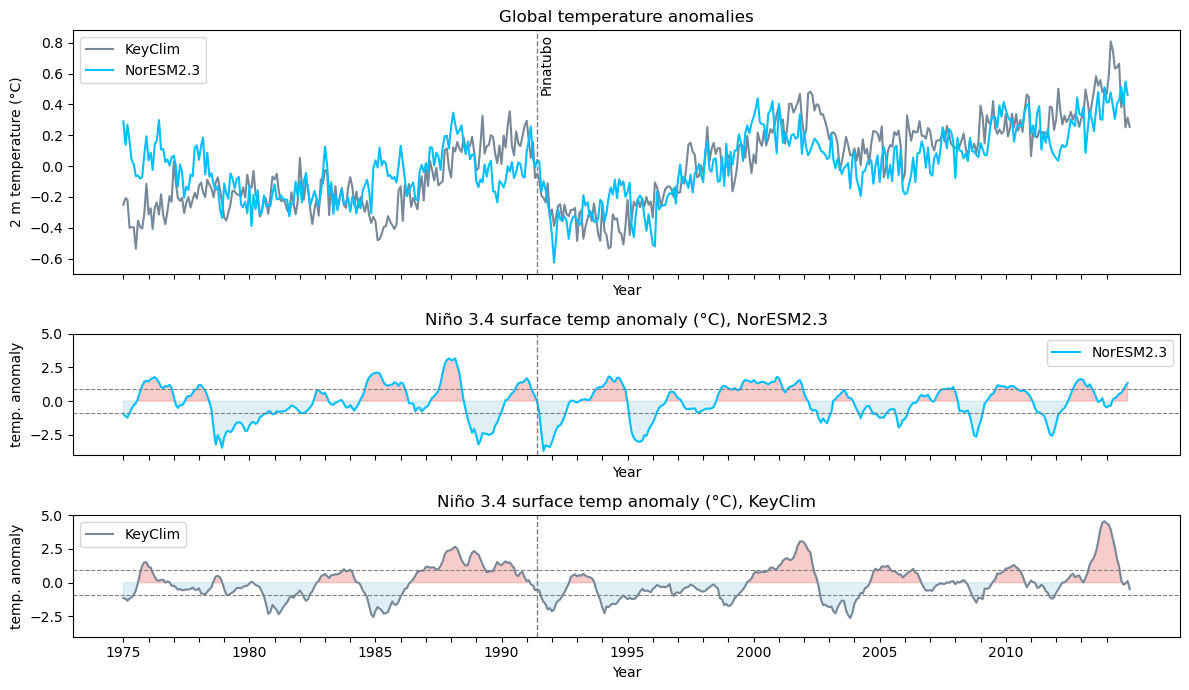

In [52]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 7), sharex=True, height_ratios=[2, 1, 1])

ts_KeyClim_anom.plot(ax=ax1, color="lightslategray", label="KeyClim")
ts_anom.plot(ax=ax1, color="deepskyblue", label="NorESM2.3")

ax1.set_ylabel("2 m temperature (°C)")
ax1.set_xlabel("Year")
ax1.set_title("Global temperature anomalies")
ax1.legend()

ax1.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="gray", linestyle="--", lw=1)
ax1.text(cftime.DatetimeNoLeap(1991, 7, 1), ax1.get_ylim()[1]-0.4, "Pinatubo", rotation=90, color="k")

time = sst_enso["time"].values
values = sst_enso.values

ax2.plot(time, values, color="deepskyblue", label="NorESM2.3")
ax2.fill_between(time, 0, values, where=values >= 0, color="lightcoral", alpha=0.4)
ax2.fill_between(time, 0, values, where=values <= 0, color="lightblue", alpha=0.4)
ax2.legend()

ax2.axhline(threshold, color="gray", linestyle="--", lw=0.8)
ax2.axhline(-threshold, color="gray", linestyle="--", lw=0.8)
ax2.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="gray", linestyle="--", lw=1)

ax2.set_title("Niño 3.4 surface temp anomaly (°C), NorESM2.3")
ax2.set_ylabel("temp. anomaly")
ax2.set_ylim(-4, 5)
ax2.set_xlabel("Year")

time_KeyClim = sst_enso_KeyClim["time"].values
values_KeyClim = sst_enso_KeyClim.values

ax3.plot(time_KeyClim, values_KeyClim, color="lightslategray", label="KeyClim")
ax3.fill_between(time_KeyClim, 0, values_KeyClim, where=values_KeyClim >= 0, color="lightcoral", alpha=0.4)
ax3.fill_between(time_KeyClim, 0, values_KeyClim, where=values_KeyClim <= 0, color="lightblue", alpha=0.4)
ax3.legend()

ax3.axhline(threshold, color="gray", linestyle="--", lw=0.8)
ax3.axhline(-threshold, color="gray", linestyle="--", lw=0.8)
ax3.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color="gray", linestyle="--", lw=1)

ax3.set_title("Niño 3.4 surface temp anomaly (°C), KeyClim")
ax3.set_ylabel("temp. anomaly")
ax3.set_ylim(-4, 5)
ax3.set_xlabel("Year")

years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax3.set_xticks(year_ticks)
ax3.set_xticklabels([str(y) if y % 5 == 0 else "" for y in years])

plt.tight_layout()
plt.show()


## Precipitation

In [53]:
conv_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/PRECC_h0_1975-2014.nc")
large_scale_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/PRECL_h0_1975-2014.nc")

conv_KeyClim =conv_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(conv_KeyClim["time"].values[:5])

large_scale_KeyClim =large_scale_KeyClim.assign_coords(time=shifted_time_KeyClim)
print(large_scale_KeyClim["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]
[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


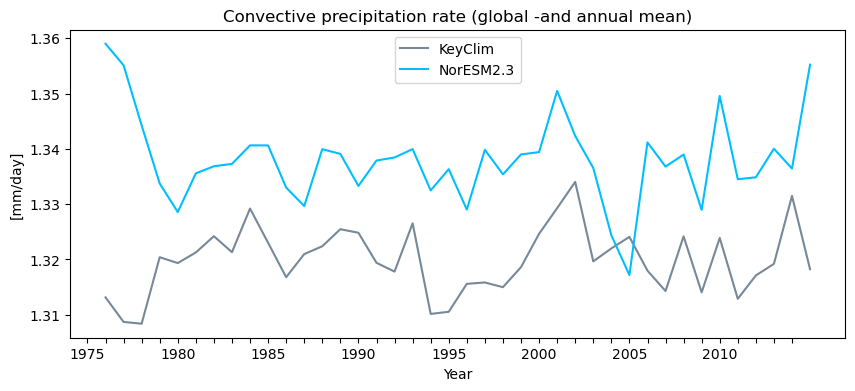

In [54]:
convective = "PRECC"
large_scale = "PRECL"

conv_prec = ds[convective].weighted(weighted_lat).mean(dim=["lat", "lon"])
conv_prec_year = conv_prec.resample(time="1YE").mean(dim="time") *60*60*24 *1000
conv_prec_KeyClim = conv_KeyClim[convective].weighted(weighted_lat).mean(dim=["lat", "lon"])
conv_prec_year_KeyClim = conv_prec_KeyClim.resample(time="1YE").mean(dim="time") *60*60*24 *1000

plt.figure(figsize=(10, 4))
conv_prec_year_KeyClim.plot(color = "lightslategray", label = "KeyClim")
conv_prec_year.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[mm/day]")
plt.title("Convective precipitation rate (global -and annual mean)")
plt.legend()
plt.show()

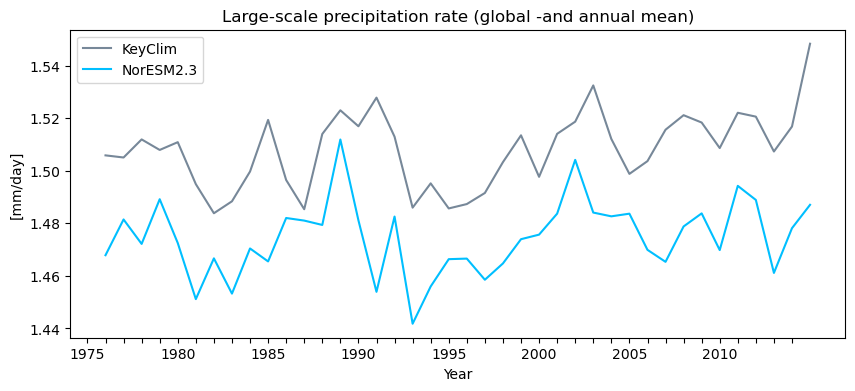

In [55]:
large_scale_prec = ds[large_scale].weighted(weighted_lat).mean(dim=["lat", "lon"])
large_scale_prec_year = large_scale_prec.resample(time="1YE").mean(dim="time") *60*60*24 *1000
large_scale_prec_KeyClim = large_scale_KeyClim[large_scale].weighted(weighted_lat).mean(dim=["lat", "lon"])
large_scale_prec_year_KeyClim = large_scale_prec_KeyClim.resample(time="1YE").mean(dim="time") *60*60*24*1000

plt.figure(figsize=(10, 4))
large_scale_prec_year_KeyClim.plot(color = "lightslategray", label = "KeyClim")
large_scale_prec_year.plot(color = "deepskyblue", label ="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.xlabel("Year")
plt.ylabel("[mm/day]")
plt.title("Large-scale precipitation rate (global -and annual mean)")
plt.legend()
plt.show()


## OH at different levels

In [56]:
oh_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/OH_h0_1975-2014.nc")
oh_KeyClim =oh_KeyClim.assign_coords(time=shifted_time_KeyClim)

In [57]:
oh_surface = ds["OH"].isel(lev=-1).weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_10km = ds["OH"].sel(lev=265, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_20km = ds["OH"].sel(lev=64.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_25km = ds["OH"].sel(lev=54.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])

oh_surface_KeyClim = oh_KeyClim["OH"].isel(lev=-1).weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_10km_KeyClim = oh_KeyClim["OH"].sel(lev=265, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_20km_KeyClim = oh_KeyClim["OH"].sel(lev=64.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])
oh_25km_KeyClim = oh_KeyClim["OH"].sel(lev=54.7, method="nearest").weighted(weighted_lat).mean(dim=["lat", "lon"])

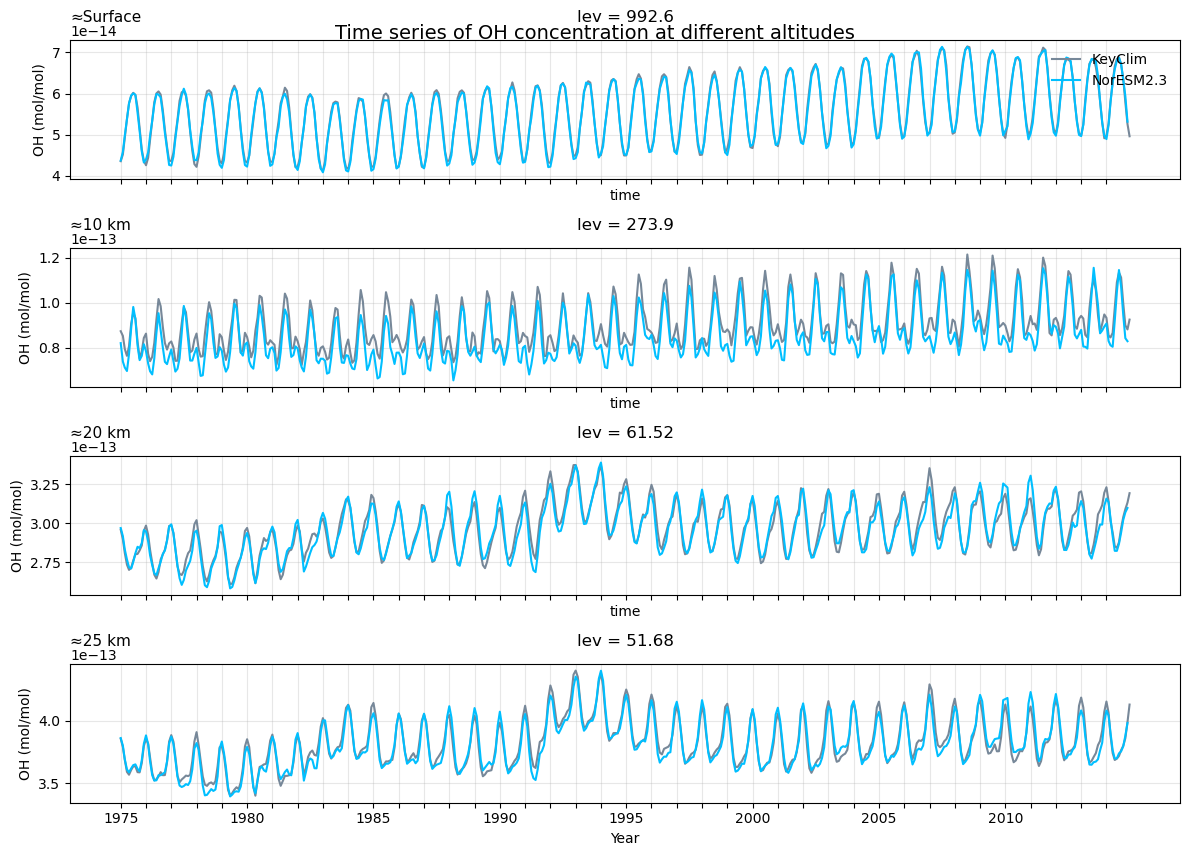

In [58]:
fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

labels = ["≈Surface", "≈10 km", "≈20 km", "≈25 km"]
series = [oh_surface, oh_10km, oh_20km, oh_25km]
series_keyclim = [oh_surface_KeyClim, oh_10km_KeyClim, oh_20km_KeyClim, oh_25km_KeyClim]

for i, (noresm, keyclim, label) in enumerate(zip(series, series_keyclim, labels)):
    keyclim.plot(ax=ax[i], color="lightslategray", label="KeyClim")
    noresm.plot(ax=ax[i], color="deepskyblue", label="NorESM2.3")

    ax[i].set_ylabel("OH (mol/mol)")
    ax[i].set_title(label, loc="left", fontsize=11, pad=2)
    ax[i].grid(alpha=0.3)
    if i == 0:
        ax[i].legend(frameon=False, loc="upper right")

years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax[-1].set_xticks(year_ticks)
ax[-1].set_xticklabels([str(y) if y % 5 == 0 else "" for y in years])
ax[-1].set_xlabel("Year")

plt.suptitle("Time series of OH concentration at different altitudes", fontsize=14, y=0.93)
plt.tight_layout()
plt.show()

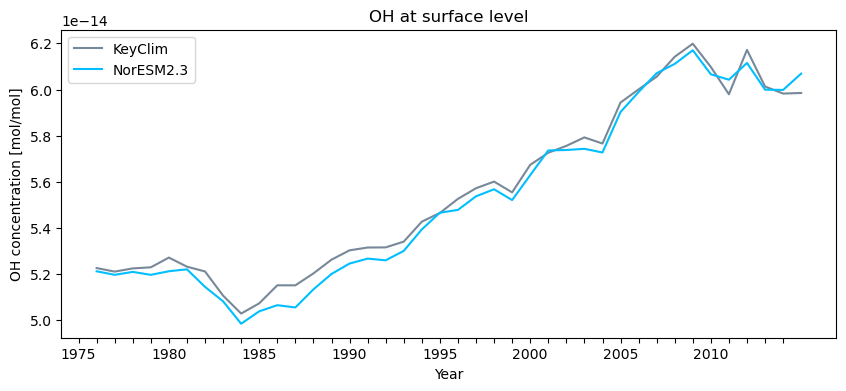

In [59]:
oh_surf_year = oh_surface.resample(time="1YE").mean(dim="time")
oh_surf_year_KeyClim = oh_surface_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
oh_surf_year_KeyClim.plot(color="lightslategray", label="KeyClim")
oh_surf_year.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("OH concentration [mol/mol]")
plt.xlabel("Year")
plt.title("OH at surface level")
plt.legend()
plt.show()


In [60]:
so2_surf = ds["SO2_SRF"].weighted(weighted_lat).mean(dim=["lat", "lon"])
so2_KeyClim = xr.open_dataset("/nird/projects/NS1004K/elihho/test_output/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/SO2_SRF_h0_1975-2014.nc")
so2_KeyClim = so2_KeyClim.assign_coords(time=shifted_time_KeyClim)

so2_surf_KeyClim = so2_KeyClim["SO2_SRF"].weighted(weighted_lat).mean(dim=["lat", "lon"])

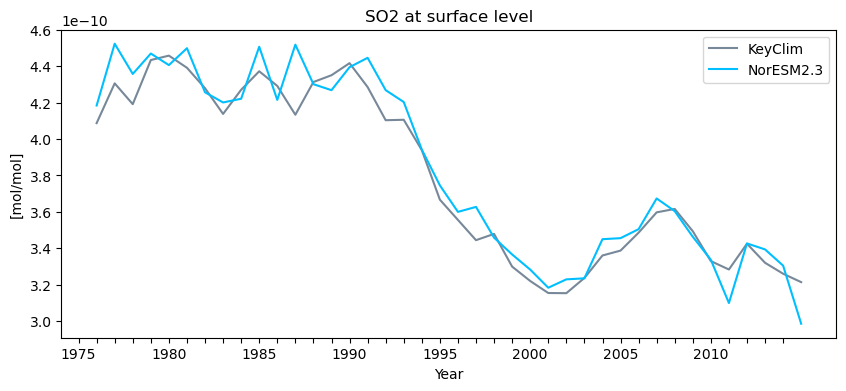

In [62]:
so2_surf = so2_surf.resample(time="1YE").mean(dim="time")
so2_surf_KeyClim = so2_surf_KeyClim.resample(time="1YE").mean(dim="time")

plt.figure(figsize=(10, 4))
so2_surf_KeyClim.plot(color="lightslategray", label="KeyClim")
so2_surf.plot(color="deepskyblue", label="NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("[mol/mol]")
plt.xlabel("Year")
plt.title("SO2 at surface level")
plt.legend()
plt.show()